<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" /> 
    
    
## <font color='navy'> Repaso Pandas
    
### <font color='navy'> Portafolios de Inversión

    Mtro. Sean Nicolás González Vázquez
    

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://upload.wikimedia.org/wikipedia/commons/e/ed/Pandas_logo.svg" width="400px" height="400px" />

> Hoy nos dedicaremos a recordar funciones clave la librería de Python para análisis de datos: **Pandas**. Durante el transcurso de la asignatura haremos uso extensivo de datos históricos de precios y rendimientos de activos financieros, por tanto es importante tener un buen manejo de pandas.

Referencias:
- https://pandas.pydata.org/
- https://towardsdatascience.com/data-science-with-python-intro-to-loading-and-subsetting-data-with-pandas-9f26895ddd7f
___


# 0. Motivación

En finanzas, normalmente trabajamos con grandes cantidades de datos (precios, rendimientos y fundamentales). 

Los datos que debemos cargar pueden guardarse de muchas maneras distintas: archivos CSV, archivos de Excel, etcétera. Incluso, los datos pueden estar disponibles a través de API's (Application Programming Interface). 

Para trabajar con datos, se hace necesario representarlos en una estructura tabular (cualquier cosa con forma de tabla con filas y columnas).

En algunos casos, los datos ya están en forma tabular y es más fácil cargarlos. En otros, debemos trabajar con datos no estructurados o que no están organizados de una manera determinada (texto plano, imágenes, audio, etcétera).

En esta clase nos vamos a concentrar en cargar datos desde archivos xlsx y desde la API de Yahoo Finance.

## Pandas


In [40]:
# Importar pandas
import pandas as pd 

___
# 1. Importando datos

En CANVAS, podrán encontrar el archivo "customers_data.xlsx" que cuenta con la información de los clientes de cierta empresa.

El primer paso para comenzar a trabajar con datos es importarlos. Lo podemos hacer con la función `pd.read_excel()`, ya que es un archivo .xlsx, en caso de necesitar exportar un archivo separado por comas (.csv) se puede utilizar la función `pd.read_csv()`:

In [41]:
# Importar customers_data.xlsx
data =pd.read_excel('customers_data.xlsx')   
data.head()

,Unnamed: 0,customer,zip_code,join_date,date_of_birth
0,0,Pedro,60091,2011-04-17 10:48:00,1994-07-18
1,1,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
2,2,Luis,13244,2011-08-13 15:42:00,2012-11-21
3,3,Cesar,60091,2011-04-08 20:08:00,2010-08-15
4,4,Pablo,60091,2010-07-17 05:27:00,1984-07-28


In [42]:
# Observar datos

Bien, ya tenemos los datos cargados, sin embargo, se ve algo raro. 

¿Qué es esta columna "Unnamed: 0"?

Para especificar que esta columna corresponde al índice, podemos usar el argumento `index_col`, o bien, la función `set_index`, debido a que los datos ya fueron exportados.

In [43]:
# Importar customers_data.xlsx, haciendo uso del argumento index_col
data=data.set_index(['Unnamed: 0'])
data

,customer,zip_code,join_date,date_of_birth
Unnamed: 0,,,,
0,Pedro,60091,2011-04-17 10:48:00,1994-07-18
1,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
2,Luis,13244,2011-08-13 15:42:00,2012-11-21
3,Cesar,60091,2011-04-08 20:08:00,2010-08-15
4,Pablo,60091,2010-07-17 05:27:00,1984-07-28


In [44]:
# Utilizar set_index, tener cuidado


In [45]:
# Ver data

In [46]:
# Tipo de objeto con que importa pandas los archivos
type(data)

pandas.core.frame.DataFrame

___
# 2. Indización y selección de datos

Hay muchas formas de las cuales podemos seleccionar datos de DataFrames. Veremos, la forma basada en corchetes ([]) y en los métodos `loc()` y `iloc()`.

Podemos empezar seleccionando con corchetes:

In [47]:
# Seleccionar la columna date_of_birth

In [48]:
#Tipo de objeto
type(data['date_of_birth'])

pandas.core.series.Series

Las Series de pandas son arreglos unidimensionales que pueden ser etiquetados. En algunos casos, querremos seleccionar solo una columna pero mantener esta selección en un DataFrame. En este caso podemos pasar una lista con un solo elemento:

In [49]:
# Seleccionar la columna date_of_birth como DataFrame
# 1[] serie 2[[]] DataFrame
#iloc filas loc columnas 
data[['date_of_birth']]
     

,date_of_birth
Unnamed: 0,
0,1994-07-18
1,1986-08-18
2,2012-11-21
3,2010-08-15
4,1984-07-28


In [50]:
# Tipo de objeto

Finalmente, seleccionamos dos columnas:

In [51]:
# Seleccionar las columnas date_of_birth y zip_code



Muy bien, ya vimos que los corchetes son útiles. También existen los poderosos métodos `loc` y `iloc`, que nos dan el poder de seleccionar ambos a la vez: columnas y filas.

¿En qué se diferencian?

- El método `loc` nos permite seleccionar filas y columnas de nuestros datos basados en etiquetas. Primero, se deben especificar las etiquetas de las filas, y luego las de las columnas.

- El método `iloc` nos permite hacer lo mismo pero basado en índices enteros de nuestro DataFrame (como si fueran matrices).

Como antes, si queremos seleccionar todas las filas, o columnas, simplemente escribimos `:` en el lugar adecuado.

Mejor con ejemplos:

Para un mejor entendimiento de esta parte, reetiquetaremos la numeración de clientes con una "numeración" alfabética. Es decir: 1 = A, 2 = B, ..., 5 = E.

In [16]:
# Utilizar data.index
data.index=['A','B','C','D','E']

In [17]:
# Observar datOS
data

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21
D,Cesar,60091,2011-04-08 20:08:00,2010-08-15
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


Ahora sí.

Seleccionemos el primer cliente con ambos métodos:

In [18]:
# Primer cliente con loc como serie
data.loc[['A'],['zip_code']] # .loc [[nombre_filas],[nombre_columnas ]]

,zip_code
A,60091


In [19]:
# Primer cliente con iloc como data frame
data.iloc[[0],[1]]#.iloc[[indice_filas],[indice_columnas]]

,zip_code
A,60091


Ahora, seleccionemos los clientes A y C con ambos métodos (.loc y .iloc):

In [20]:
# Clientes A y C con loc
data.loc[['A','C']]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21


In [21]:
# Clientes A y C con iloc
data.iloc[[0,2]]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21


Ahora, de los clientes B y E, queremos su zip_code y su join_date:

In [22]:
# loc 
# Ahora, de los clientes B y E, queremos su zip_code y su join_date:
data.loc[['B','E'],['zip_code','join_date']]


,zip_code,join_date
B,13244,2012-04-15 23:31:00
E,60091,2010-07-17 05:27:00


In [23]:
# iloc 
# Ahora, de los clientes B y E, queremos su zip_code y su join_date:
data.iloc[[1,4],[1,2]] # .iloc [[indice_filas],[indice_columnas]]


,zip_code,join_date
B,13244,2012-04-15 23:31:00
E,60091,2010-07-17 05:27:00


___
# 3. Filtrado de datos

Los operadores de comparación pueden ser utilizados con Series de pandas. 

Esto resulta ser súper útil para filtrar datos con ciertas condiciones específicas (esto lo veremos enseguida). 

Por ahora, veremos que al usar operadores de comparación con Series, el resultado será Series booleanas. Es decir, cada elemento de dichas series será `True` si la condición se satisface, y `Falso` de lo contrario.

Una vez tenemos la serie boolena, podemos aplicarla para la selección de filas, obteniendo un DataFrame filtrado como resultado.

**Ejemplos**

¿Cuáles clientes son mayores de 18 años?

In [24]:
# Ver tabla
data

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21
D,Cesar,60091,2011-04-08 20:08:00,2010-08-15
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


In [25]:
# Cuales son mayores de edad?
data['date_of_birth']<'2008-01-01'

A     True
B     True
C    False
D    False
E     True
Name: date_of_birth, dtype: bool

In [26]:
# Filtrar data frame
data[data['date_of_birth']<'2008-01-01']

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


¿Cuáles clientes viven en la zona con CP 13244?

In [27]:
# Zone True or False
data['zip_code']=='13244'

A    False
B    False
C    False
D    False
E    False
Name: zip_code, dtype: bool

In [28]:
# Filtrar data frame
data[data['zip_code']=='13244']

,customer,zip_code,join_date,date_of_birth


# 4.- Importación de Datos desde Yahoo Finance

La librería de Yahoo Finance `yfinance`, nos permite descargar directamente datos desde la base de datos de Yahoo Finance, la documentación de la paquetería es la siguiente:

+ https://pypi.org/project/yfinance/

Para instalar la librería desde tu computadora utiliza el comando:

`!pip install yfinance`

In [29]:
# Importar y/o instalar yfinance
#!pip install yfinance
#!pip install yfinance--upgrade (si la api no funiciona )
import yfinance as yf

Con el método de `yf.download`, podemos descargar la información de cualquier activo financiero que cotice en la bolsa de Estados Unidos (**NYSE**), utilizando el *Ticker* del activo, vamos a intentarlo para una acción:

In [30]:
# Descargar información para un activo y guardar en variable "price"
price=yf.download('PLTR',start='2026-01-01',end='2026-08-18')
len(price) # te da el número de filas del data frame


/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_60675/2472296801.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price=yf.download('PLTR',start='2026-01-01',end='2026-08-18')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PLTR']: Timeout('Failed to perform, curl: (28) Connection timed out after 30001 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


0

Notesé que la función descarga distinta información de los activos, como por ejemplo el Low, Close, Adj Close, etc. 

Vamos a analizar cada elemento para discutir cual es el más importante, a posteriori, vamos a filtrar el data frame por esta columna.

In [31]:
# Filtrar price por la columna más importante
price['Close']

Ticker,PLTR
Date,


También podemos intentarlo para *n* cantidad de activos, además de la acción descargada en la parte anterior, vamos a descargar ahora la información de JP Morgan `JPM` y del índice Dow Jones `^DJI`, y filtrando por la columna determinada en la parte anterior.

In [32]:
# Descargar la información para la acción anterior, JPM y DJI.
price=yf.download(['PLTR','NVDA','DJI'],start='2010-01-01',end='2026-08-18')['Close'] 
price

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_60675/3522136477.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price=yf.download(['PLTR','NVDA','DJI'],start='2010-01-01',end='2026-08-18')['Close']
[*********************100%***********************]  3 of 3 completed

1 Failed download:
['DJI']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2026-08-18)')


Ticker,DJI,NVDA,PLTR
Date,,,
2010-01-04,NaN,0.422817,NaN
2010-01-05,NaN,0.428991,NaN
2010-01-06,NaN,0.431736,NaN
2010-01-07,NaN,0.423275,NaN
2010-01-08,NaN,0.424189,NaN
...,...,...,...
2026-08-11,NaN,217.256897,174.940002
2026-08-12,NaN,223.839523,171.039993
2026-08-13,NaN,225.048187,179.009995


Podemos observar en el dataframe anterior que tenemos valores nulos en algunos activos, esto debido a que los activos empezaron a cotizar en momentos históricos diferentes o no tenemos acceso al período solicitado. Vamos a filtrar el período para después del 2018.

In [33]:
# Filtrar df para los datos después del 2018
df=price[price.index>'2018-01-01']
df

Ticker,DJI,NVDA,PLTR
Date,,,
2018-01-02,NaN,4.917026,NaN
2018-01-03,NaN,5.240636,NaN
2018-01-04,NaN,5.268261,NaN
2018-01-05,NaN,5.312905,NaN
2018-01-08,NaN,5.475697,NaN
...,...,...,...
2026-08-11,NaN,217.256897,174.940002
2026-08-12,NaN,223.839523,171.039993
2026-08-13,NaN,225.048187,179.009995


Para no tener que filtrar siempre el dataframe, podemos directamente descargar la información para un periodo dato, utilizando los parámetros `start` y `ènd` de la función `yf.download()`

In [34]:
# Descargar información con un período dado
yf.download(['PLTR','NVDA','DJI'], start='2010-01-01',end='2026-08-18', interval='5d')

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_60675/2797358260.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(['PLTR','NVDA','DJI'], start='2010-01-01',end='2026-08-18', interval='5d')
[*********************100%***********************]  3 of 3 completed

1 Failed download:
['DJI']: YFPricesMissingError('possibly delisted; no price data found  (5d 2010-01-01 -> 2026-08-18)')


Price      Adj Close Close                         High              \
Ticker           DJI   DJI        NVDA        PLTR  DJI        NVDA   
Date                                                                  
2010-01-06       NaN   NaN    0.431736         NaN  NaN    0.432650   
2010-01-11       NaN   NaN    0.418244         NaN  NaN    0.428305   
2010-01-21       NaN   NaN    0.389888         NaN  NaN    0.403837   
2010-01-26       NaN   NaN    0.370680         NaN  NaN    0.383485   
2010-02-05       NaN   NaN    0.370908         NaN  NaN    0.371823   
...              ...   ...         ...         ...  ...         ...   
2026-07-16       NaN   NaN  207.168182  134.440002  NaN  210.844077   
2026-07-21       NaN   NaN  207.058304  132.660004  NaN  208.416784   
2026-07-31       NaN   NaN  200.525620  123.059998  NaN  201.774222   
2026-08-05       NaN   NaN  218.974976  158.429993  NaN  221.971622   
2026-08-10       NaN   NaN  217.306839  175.229996  NaN  223.889469   

Price                  Low                         Open              \
Ticker            PLTR DJI        NVDA        PLTR  DJI        NVDA   
Date                                                                  
2010-01-06         NaN NaN    0.424647         NaN  NaN    0.428763   
2010-01-11         NaN NaN    0.412298         NaN  NaN    0.426476   
2010-01-21         NaN NaN    0.386230         NaN  NaN    0.396748   
2010-01-26         NaN NaN    0.370451         NaN  NaN    0.380970   
2010-02-05         NaN NaN    0.356731         NaN  NaN    0.363134   
...                ...  ..         ...         ...  ...         ...   
2026-07-16  136.210007 NaN  205.619927  128.679993  NaN  209.935091   
2026-07-21  134.679993 NaN  203.781971  131.225006  NaN  207.308024   
2026-07-31  123.389999 NaN  194.732099  119.620003  NaN  198.218204   
2026-08-05  166.080002 NaN  216.158120  158.250000  NaN  216.617613   
2026-08-10  179.600006 NaN  216.527712  170.869995  NaN  223.150291   

Price                  Volume                         
Ticker            PLTR    DJI       NVDA        PLTR  
Date                                                  
2010-01-06         NaN    NaN  649168000         NaN  
2010-01-11         NaN    NaN  556612000         NaN  
2010-01-21         NaN    NaN  608632000         NaN  
2010-01-26         NaN    NaN  714636000         NaN  
2010-02-05         NaN    NaN  604856000         NaN  
...                ...    ...        ...         ...  
2026-07-16  133.080002    NaN  122986100  28951300.0  
2026-07-21  133.830002    NaN  108685600  23161800.0  
2026-07-31  122.290001    NaN  139961200  29085100.0  
2026-08-05  162.000000    NaN  158187400  63515900.0  
2026-08-10  171.009995    NaN  115846600  57402700.0  

[837 rows x 16 columns]

Ahora, si queremos graficar la información con los precios de cierre ajustado para nuestras tres acciones, vamos a utilizar `matplotlib.pyplot`:

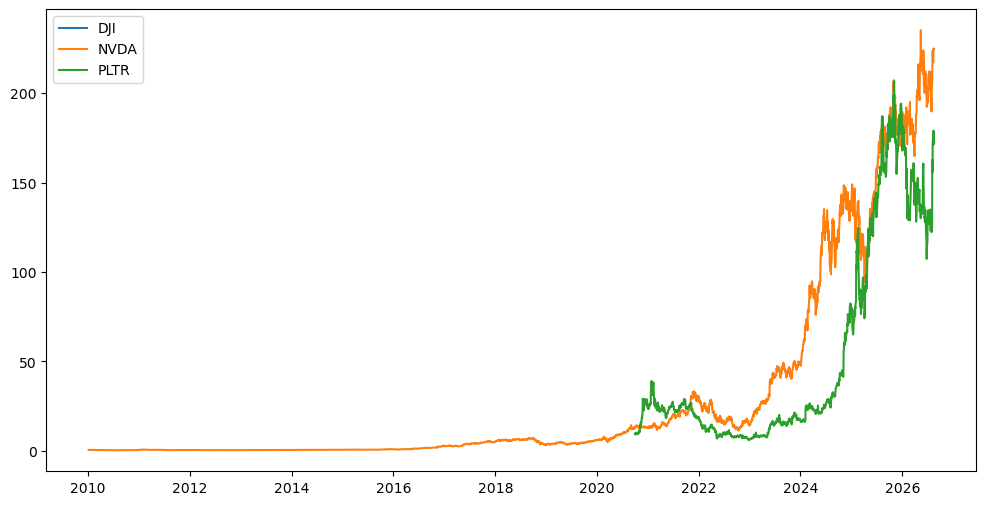

In [35]:
# Graficar precios usando matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(price, label=price.columns)
plt.legend()
plt.show()

Como pueden observar, el Dow Jones se encuentra en una escala de precios muy por encima del resto de las acciones, hay que reflexionar: ¿A qué se debe esto? ¿Es útil comparar los precios de un activo financiero para decidir si invertir o no en este?

In [36]:
# Filtrar precios quitando el Dow Jones
filtered= price.drop(['DJI'], axis=1)


/opt/anaconda3/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


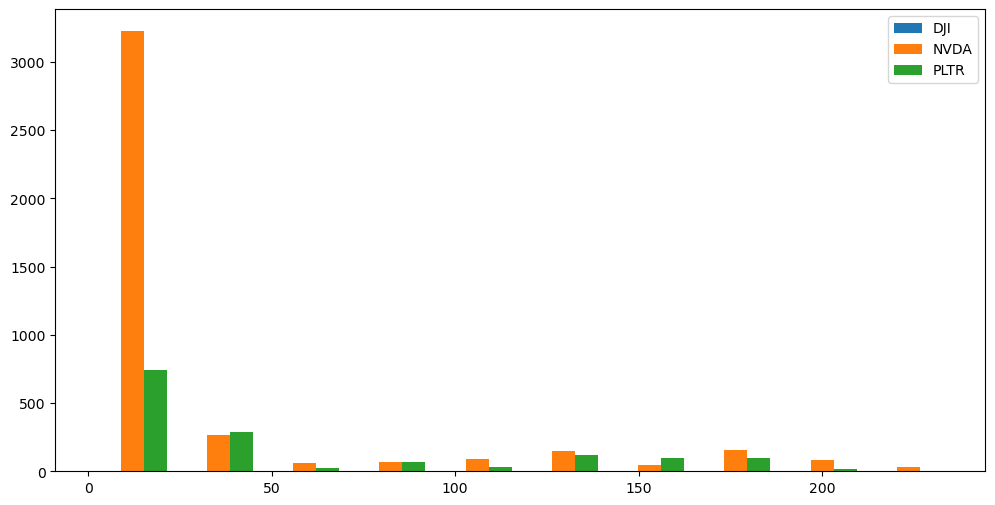

In [37]:
# Graficar precios usando matplotlib
plt.figure(figsize=(12,6))
plt.hist(price, label=price.columns)
plt.legend()
plt.show()

> **Útil, ¿no?**.  Como habrán notado, la librería pandas es una herramienta extremadamente poderosa, no solo para el análisis de datos en Python, sino también para la manipulación y análisis de datos financieros. Durante el curso, utilizaremos esta librería para almacenar información sobre activos financieros, como precios, rendimientos, métricas de desempeño y más.

> En los últimos cinco años, la programación y las matemáticas han adquirido un papel crucial en las finanzas. De hecho, el **CFA Institute**, la organización de finanzas más prestigiosa a nivel mundial, ha incorporado temas de programación en Python y Ciencia de Datos en su certificación. Además, numerosas empresas bursátiles han comenzado a adoptar Python como el lenguaje preferido para el desarrollo de aplicaciones financieras. Esto subraya la importancia de comprender y dominar Python en el campo de la Ingeniería Financiera.